## Gather skiver results

In [1]:
import pandas as pd
import glob

output_dir="../../output/multiple_alleles"
prefix = "Ecoli_K12_MG1655"

id = [100, 98, 96, 94, 92, 90]
ratio = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Initialize list to store results as a df
identity = []
ratio_list = []
lambda_estimates = []
beta_estimates = []
with_filter = []

for i in id:
    for r in ratio:

        #print(f"Processing identity {i} and ratio {r}")
        lambda_list = []
        b_list = []
        coverage_list = []
        
        output_file_name = f"{output_dir}/{prefix}_ratio_{r}_id_{i}_exp_[0-9+]_bi.csv"
        output_file_no_filter_name = f"{output_dir}/{prefix}_ratio_{r}_id_{i}_exp_[0-9+]_bi_no_filter.csv"
        all_files = glob.glob(output_file_name)
        for file in all_files:
            df = pd.read_csv(file)


            lambda_estimates.append(df['lambda'].item())
            beta_estimates.append(df['beta'].item())
            identity.append(i)
            ratio_list.append(r)
            with_filter.append('With filter')
        
        all_files = glob.glob(output_file_no_filter_name)
        for file in all_files:
            df = pd.read_csv(file)

            lambda_estimates.append(df['lambda'].item())
            beta_estimates.append(df['beta'].item())
            identity.append(i)
            ratio_list.append(r)
            with_filter.append('Without filter')


In [2]:
import numpy as np

result_df = pd.DataFrame({
    'identity': identity,
    'ratio': ratio_list,
    'lambda_estimate': lambda_estimates,
    'beta_estimate': beta_estimates,
    'with_filter': with_filter
})
result_df['error_estimate'] = 1 - np.exp(-result_df['lambda_estimate'])

## Get ground truth error rate

<>:67: SyntaxWarning: invalid escape sequence '\h'
<>:67: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1856569/3383204451.py:67: SyntaxWarning: invalid escape sequence '\h'
  math_label = '$\hat{S}(t) = e^{-%.4ft^{%.4f}}$' % (l, bet)
/tmp/ipykernel_1856569/3383204451.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_1856569/3383204451.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_1856569/3383204451.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_1856569/3383204451.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_

Fitted parameters: alpha = 1.000000, beta = 1.000000
Fitted parameters: alpha = 0.979372, beta = 1.000000
Fitted parameters: alpha = 0.958953, beta = 1.000000
Fitted parameters: alpha = 0.938381, beta = 1.000000
Fitted parameters: alpha = 0.917697, beta = 1.000000
Fitted parameters: alpha = 0.896852, beta = 1.000000


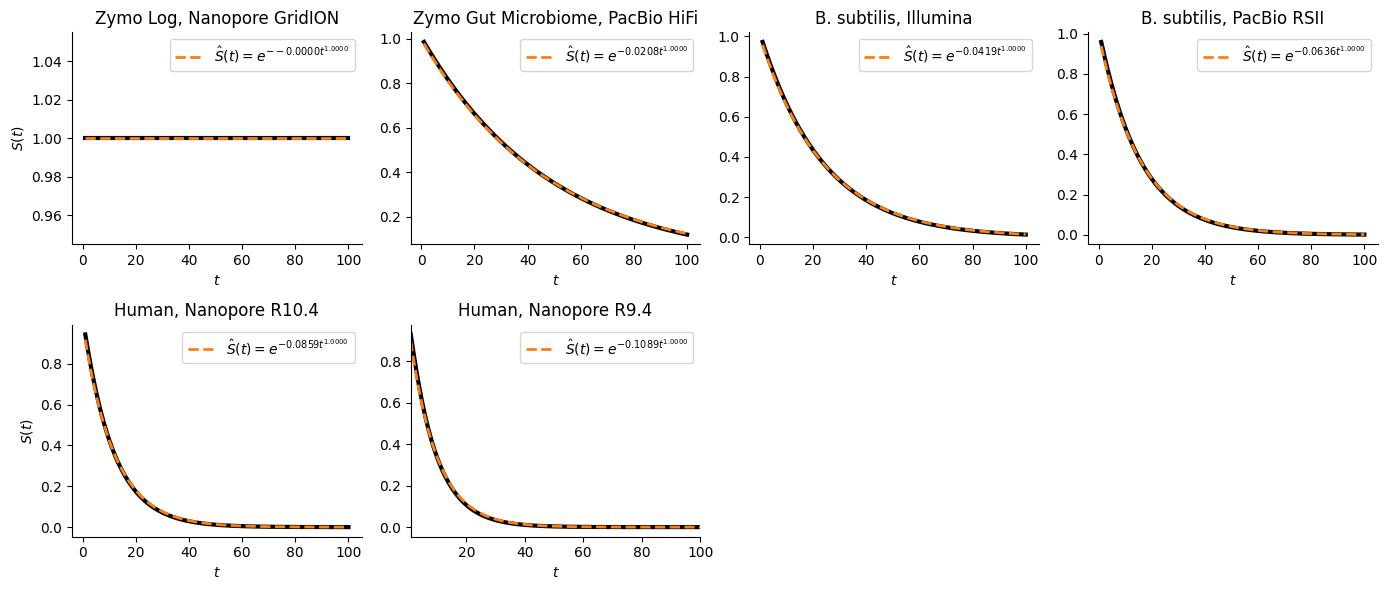

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns


# Define the function to fit
def fit_function_constant(i, alpha, beta):
    return np.exp(- alpha - beta * i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean * i + (std ** 2) * (i ** 2) / 2)

def fit_function_discrete_weibull(i, l, k):
    return l ** ((i) ** 1)


kmer_hit_rate_csv = [
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_100.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_98.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_96.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_94.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_92.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_90.matched_kmers.csv",
]

labels = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio HiFi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
    "Human, Nanopore R10.4",
    "Human, Nanopore R9.4",
    "Human, PacBio HiFi"
]

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
hazard_ratio_plot_range = range(1, 101)
hazard_ratio_estimate_range = range(1, 101)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

ground_truth_lambda = []

func = fit_function_discrete_weibull
#func = fit_function_constant

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values

    
    survival_rates_esimates = survival_rates[hazard_ratio_estimate_range.start - 1:hazard_ratio_estimate_range.stop - 1]
    survival_rates_plot = survival_rates[hazard_ratio_plot_range.start - 1:hazard_ratio_plot_range.stop - 1]
    
    # Fit the curve alpha/(alpha + beta + t) to the hazard ratios
    params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
    alpha, bet = params
    print(f"Fitted parameters: alpha = {alpha:.6f}, beta = {bet:.6f}")
    l = -np.log(alpha)
    ground_truth_lambda.append(l)

    math_label = '$\hat{S}(t) = e^{-%.4ft^{%.4f}}$' % (l, bet)

    #axes[i].set_yscale('log')
    #axes[i].set_xscale('log')

    axes[i].plot(hazard_ratio_plot_range, survival_rates_plot, linewidth=3, color='black')
    fitted_hazard_ratios = [func(t, alpha, bet) for t in hazard_ratio_plot_range]
    axes[i].plot(hazard_ratio_plot_range, fitted_hazard_ratios, linewidth=2, linestyle='--', label=math_label, color='C1')
    
    axes[i].tick_params(axis='both')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    axes[i].set_title(labels[i])
    axes[i].set_xlabel('$t$')
    if i % 4 == 0:
        axes[i].set_ylabel('$S(t)$')
    axes[i].legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.xlim(hazard_ratio_plot_range.start, hazard_ratio_plot_range.stop - 1)
plt.show()
#plt.ylim(0, 0.05)

## Change of predicted error rate with the proportion of K-12 MG1655 in the mixture

<>:31: SyntaxWarning: invalid escape sequence '\i'
<>:33: SyntaxWarning: invalid escape sequence '\i'
<>:31: SyntaxWarning: invalid escape sequence '\i'
<>:33: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_1856569/3493336922.py:31: SyntaxWarning: invalid escape sequence '\i'
  plt.xlabel("Proportion of $\it{E. coli}$ K12 MG1655 strain in the mixture")
/tmp/ipykernel_1856569/3493336922.py:33: SyntaxWarning: invalid escape sequence '\i'
  plt.title("Estimated error rates in a mixture of two $\it{E. coli}$ strains")


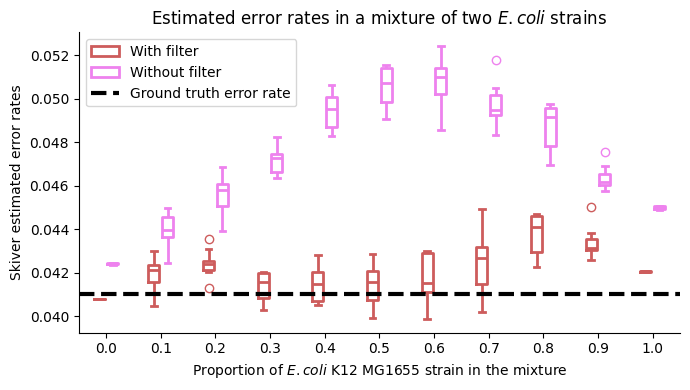

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

i = 2  # Index for 96% identity


result_df_id = result_df[result_df['identity'] == id[i]]
"""
sns.stripplot(
    data=result_df_100x, x="identity", y="error_estimate", hue="with_reference",
    dodge=True, alpha=.2, legend=False,
    palette=["indianred", "goldenrod"],
)
sns.pointplot(
    data=result_df_100x, x="identity", y="error_estimate", hue="with_reference",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=20, markeredgewidth=3,
    palette=["indianred", "goldenrod"],
)
"""
fig = plt.figure(figsize=(7, 4))
plt.rc('axes.spines', **{'bottom':True, 'left':True, 'right':False, 'top':False})
sns.boxplot(
    data=result_df_id, x="ratio", y="error_estimate", hue="with_filter",
    fill=False, gap=.2,
    width=0.5,
    linewidth=2,
    flierprops={"marker": "o"},
    palette=["indianred", "violet"],
)
plt.xlabel("Proportion of $\it{E. coli}$ K12 MG1655 strain in the mixture")
plt.ylabel("Skiver estimated error rates")
plt.title("Estimated error rates in a mixture of two $\it{E. coli}$ strains")

# Plot ground truth as a lineplot
ground_truth_error = [1 - np.exp(-l) for l in ground_truth_lambda]
#plt.plot(np.arange(len(ground_truth_lambda)), ground_truth_error, color='black', marker='d', linewidth=3, label='Ground truth error rate')
plt.axhline(y=ground_truth_error[i], color='black', linewidth=3, linestyle='--', label='Ground truth error rate')
plt.legend()
#plt.ylim(0, 0.045)
plt.tight_layout()
plt.savefig("../../figures/multiple_strains.svg")